In [105]:
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
import pandas as pd
import numpy  as np
import math, json, os

pd.set_option('display.max_columns', None)

# CONFIGURAÇÕES

In [106]:
OPTIONS = json.loads(open('../../info.json', 'r', encoding='utf-8').read())
OPTIONS

{'test': 2}

In [107]:
TEST_NUM = OPTIONS['test']
PATH     = f'../files/test{TEST_NUM}'
PATH

'../files/test2'

In [108]:
TARGET_VAR  = 'pitch'
LIMITS      = json.loads(open(os.path.join(PATH, 'info.json'), 'r').read()).get('limits')
STATIC_LIMITS  = LIMITS.get('static')
DYNAMIC_LIMITS = LIMITS.get('dynamic')

print(LIMITS)
print(STATIC_LIMITS)
print(DYNAMIC_LIMITS)

{'dynamic': [30, 100], 'static': [500, 900]}
[500, 900]
[30, 100]


# IMPORTANDO DADOS

In [109]:
df = pd.read_csv(f'{PATH}/reference/data.csv')
df

,wx,az,q1,ay,la_pos_mon_d,ax,roll,q0,yaw,pitch,q3,wy,time,sample_time,wz,q2
0,0.001440,0.015840,0.6849,-9.784,0.005316,0.07949,1.569,0.6864,-0.4941,0.000633,-0.1733,-0.001633,7.152557e-07,5000000.0,-0.005333,-0.1725
1,0.003316,0.010920,0.6851,-9.785,0.005228,0.04310,1.569,0.6862,-0.4942,0.001141,-0.1735,-0.001872,3.056693e-02,105000000.0,-0.004793,-0.1724
2,0.003521,-0.005793,0.6852,-9.786,0.005136,0.03549,1.569,0.6860,-0.4942,0.001537,-0.1736,0.000285,1.198497e-01,205000000.0,-0.003965,-0.1723
3,0.003307,-0.018600,0.6853,-9.787,0.005032,0.03585,1.570,0.6859,-0.4944,0.001800,-0.1737,-0.001855,2.170892e-01,305000000.0,-0.002282,-0.1723
4,0.001317,-0.032440,0.6854,-9.787,0.004916,0.03148,1.570,0.6858,-0.4946,0.001930,-0.1739,-0.003031,3.150485e-01,405000000.0,-0.000589,-0.1723
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10067,0.000675,-0.006692,0.6482,-9.786,0.316300,0.08539,1.570,0.6405,-0.8486,0.029170,-0.3006,-0.000353,1.006646e+03,705000000.0,0.000093,-0.2815
10068,0.000430,-0.010730,0.6482,-9.786,0.316200,0.08618,1.570,0.6405,-0.8486,0.029150,-0.3007,-0.000270,1.006742e+03,805000000.0,0.000078,-0.2815
10069,0.000284,-0.013310,0.6482,-9.786,0.316100,0.08745,1.570,0.6405,-0.8487,0.029160,-0.3007,-0.000512,1.006839e+03,905000000.0,0.000067,-0.2815
10070,-0.000028,-0.013930,0.6482,-9.786,0.315900,0.08786,1.570,0.6405,-0.8487,0.029150,-0.3007,-0.000474,1.006945e+03,5000000.0,-0.000091,-0.2815


- Convertendo pra radianos

In [110]:
for col in ['wx', 'wy', 'wz', 'pitch', 'roll', 'yaw']:
    df.loc[:, col] = df[col] * 180.00/np.pi

df

,wx,az,q1,ay,la_pos_mon_d,ax,roll,q0,yaw,pitch,q3,wy,time,sample_time,wz,q2
0,0.082506,0.015840,0.6849,-9.784,0.005316,0.07949,89.897078,0.6864,-28.309845,0.036274,-0.1733,-0.093564,7.152557e-07,5000000.0,-0.305558,-0.1725
1,0.189993,0.010920,0.6851,-9.785,0.005228,0.04310,89.897078,0.6862,-28.315574,0.065374,-0.1735,-0.107258,3.056693e-02,105000000.0,-0.274619,-0.1724
2,0.201738,-0.005793,0.6852,-9.786,0.005136,0.03549,89.897078,0.6860,-28.315574,0.088064,-0.1736,0.016346,1.198497e-01,205000000.0,-0.227178,-0.1723
3,0.189477,-0.018600,0.6853,-9.787,0.005032,0.03585,89.954374,0.6859,-28.327033,0.103132,-0.1737,-0.106284,2.170892e-01,305000000.0,-0.130749,-0.1723
4,0.075459,-0.032440,0.6854,-9.787,0.004916,0.03148,89.954374,0.6858,-28.338493,0.110581,-0.1739,-0.173664,3.150485e-01,405000000.0,-0.033759,-0.1723
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10067,0.038669,-0.006692,0.6482,-9.786,0.316300,0.08539,89.954374,0.6405,-48.621198,1.671318,-0.3006,-0.020231,1.006646e+03,705000000.0,0.005357,-0.2815
10068,0.024614,-0.010730,0.6482,-9.786,0.316200,0.08618,89.954374,0.6405,-48.621198,1.670172,-0.3007,-0.015476,1.006742e+03,805000000.0,0.004477,-0.2815
10069,0.016249,-0.013310,0.6482,-9.786,0.316100,0.08745,89.954374,0.6405,-48.626928,1.670745,-0.3007,-0.029324,1.006839e+03,905000000.0,0.003858,-0.2815
10070,-0.001590,-0.013930,0.6482,-9.786,0.315900,0.08786,89.954374,0.6405,-48.626928,1.670172,-0.3007,-0.027141,1.006945e+03,5000000.0,-0.005229,-0.2815


In [111]:
removed = df[df.duplicated(subset=['time'], keep='first')]
df      = df.drop_duplicates(subset=['time'], keep='first')
removed

,wx,az,q1,ay,la_pos_mon_d,ax,roll,q0,yaw,pitch,q3,wy,time,sample_time,wz,q2


# VISUALIZAÇÃO DE VARIÁVEIS

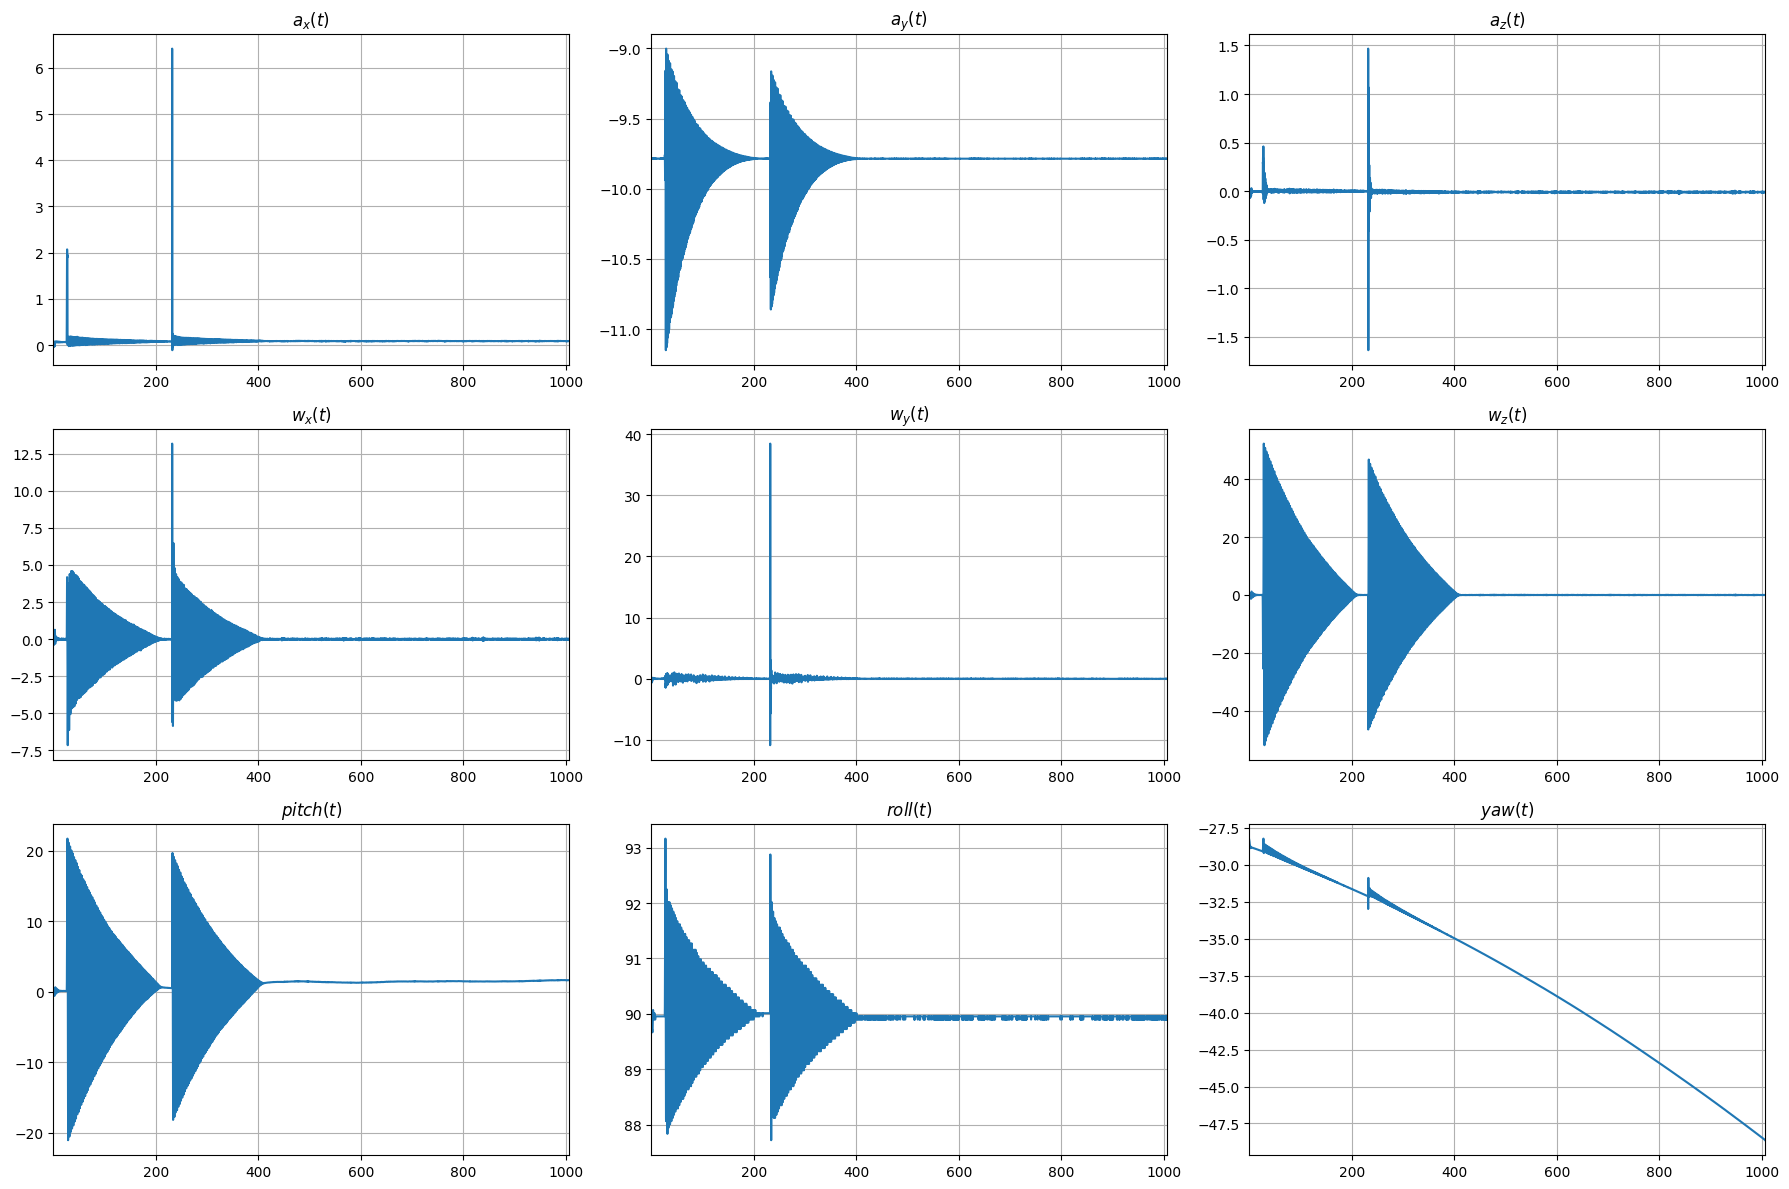

In [112]:
def compareAxis(time, data, limits=(0, 1), yLim=None):
    t_min, t_max = time.min(), time.max()
    delta = t_max - t_min
    
    start_time = t_min + (delta * limits[0])
    end_time   = t_min + (delta * limits[1])
    
    count   = len(data.keys())
    numCols = 3 if count >= 3 else count
    numRows = math.ceil(count / numCols)
    plt.figure(figsize=(6*numCols, 4*numRows))

    for i, (key, values) in enumerate(data.items()):
        mask = (time >= start_time) & (time <= end_time)
        target_time = time[mask]
        target_vals = values[mask]

        plt.subplot(numRows, numCols, i+1)
        plt.plot(target_time, target_vals)
        
        plt.xlim(start_time, end_time) 
        if yLim: plt.ylim(yLim)
        plt.title(key)
        plt.grid(True)

    plt.tight_layout()
    plt.show()

def plotAll(df, limits=(0, 1)):
    compareAxis(df.time, {
        '$a_x(t)$': df.ax, '$a_y(t)$': df.ay, '$a_z(t)$': df.az,
        '$w_x(t)$': df.wx, '$w_y(t)$': df.wy, '$w_z(t)$': df.wz,
        '$pitch(t)$': df.pitch, '$roll(t)$': df.roll, '$yaw(t)$': df.yaw
    }, limits)


plotAll(df, limits=(0, 1))

# AMOSTRAGEM

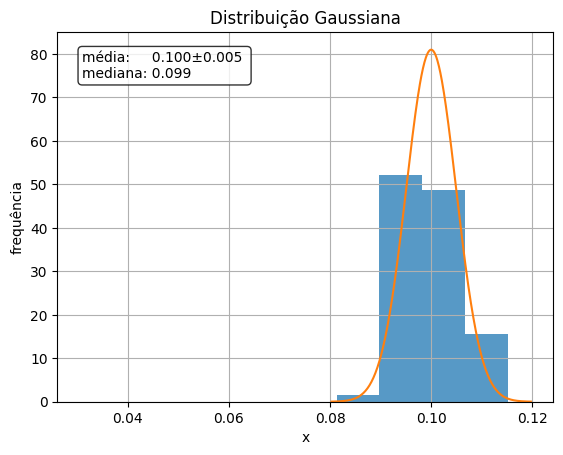

,time,wx,az,q1,ay,la_pos_mon_d,ax,roll,q0,yaw,pitch,q3,wy,sample_time,wz,q2
0,0.0,0.082506,0.015840,0.6849,-9.784,0.005316,0.07949,89.897078,0.6864,-28.309845,0.036274,-0.1733,-0.093564,5000000.0,-0.305558,-0.1725
1,0.1,0.189993,0.010920,0.6851,-9.785,0.005228,0.04310,89.897078,0.6862,-28.315574,0.065374,-0.1735,-0.107258,105000000.0,-0.274619,-0.1724
2,0.2,0.201738,-0.005793,0.6852,-9.786,0.005136,0.03549,89.897078,0.6860,-28.315574,0.088064,-0.1736,0.016346,205000000.0,-0.227178,-0.1723
3,0.3,0.189477,-0.018600,0.6853,-9.787,0.005032,0.03585,89.954374,0.6859,-28.327033,0.103132,-0.1737,-0.106284,305000000.0,-0.130749,-0.1723
4,0.4,0.075459,-0.032440,0.6854,-9.787,0.004916,0.03148,89.954374,0.6858,-28.338493,0.110581,-0.1739,-0.173664,405000000.0,-0.033759,-0.1723
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10067,1006.7,0.038669,-0.006692,0.6482,-9.786,0.316300,0.08539,89.954374,0.6405,-48.621198,1.671318,-0.3006,-0.020231,705000000.0,0.005357,-0.2815
10068,1006.8,0.024614,-0.010730,0.6482,-9.786,0.316200,0.08618,89.954374,0.6405,-48.621198,1.670172,-0.3007,-0.015476,805000000.0,0.004477,-0.2815
10069,1006.9,0.016249,-0.013310,0.6482,-9.786,0.316100,0.08745,89.954374,0.6405,-48.626928,1.670745,-0.3007,-0.029324,905000000.0,0.003858,-0.2815
10070,1007.0,-0.001590,-0.013930,0.6482,-9.786,0.315900,0.08786,89.954374,0.6405,-48.626928,1.670172,-0.3007,-0.027141,5000000.0,-0.005229,-0.2815


In [113]:
def gaussian(data):
    data  = np.array(data)
    n     = data.shape[0]
    mu    = data.mean()
    sigma = data.std()

    x  = np.linspace(mu - 4*sigma, mu + 4*sigma, 400)
    y  = (1/(sigma*np.sqrt(2*np.pi))) * np.exp(-0.5*((x - mu)/sigma)**2)
    plt.title(f'Distribuição Gaussiana')
    plt.hist(data, density=True, alpha=0.75)
    plt.plot(x, y)
    
    text = f'média:     {mu:.3f}±{sigma:.3f} \nmediana: {np.median(data):.3f}'
    opts = dict(boxstyle='round', facecolor='white', alpha=0.8)
    plt.text(0.05, 0.95, text, transform=plt.gca().transAxes, verticalalignment='top', bbox=opts)
    plt.xlabel('x'); plt.ylabel('frequência'); plt.grid()

def normalizePeriod(df, key, dt=0.15):
    df = df.copy().sort_values(key)
    df[key] = df[key] - df[key].iloc[0]

    initTime  = df[key].iloc[0]
    finalTime = df[key].iloc[-1] + dt
    n = int(np.floor((finalTime - initTime) / dt)) + 1
    newAxis = np.round(np.linspace(initTime, initTime + dt*(n-1), n), 10)
    target  = pd.DataFrame({key: newAxis})
    out = pd.merge_asof(target, df, on=key, direction='backward')
    return out


time = df.time.diff()[1:].to_numpy()
dt   = np.median(time).round(2)
dt = 0.10
gaussian(time); plt.show()
df = normalizePeriod(df, 'time', dt)
df

# SEPARAÇÃO DE TABELAS
- Juntando Amostragem pelos limites definidos

In [114]:
df_static  = df.loc[(df.time >= STATIC_LIMITS[0]) & (df.time <= STATIC_LIMITS[1])].copy()
df_dynamic = df.loc[(df.time > DYNAMIC_LIMITS[0]) & (df.time <= DYNAMIC_LIMITS[1])].copy() 

df_dynamic['static'] = False
df_static['static']  = True

df_dynamic.loc[:, 'time'] = (df_dynamic.time - df_dynamic.time.values[0])
df_static.loc[:, 'time']  = (df_static.time  - df_static.time.values[0])  + df_dynamic.time.values[-1]

df = pd.concat([df_dynamic, df_static], axis=0, ignore_index=True)
df

,time,wx,az,q1,ay,la_pos_mon_d,ax,roll,q0,yaw,pitch,q3,wy,sample_time,wz,q2,static
0,0.0,3.766625,0.189200,0.7086,-10.550,-0.08849,0.024890,91.157585,0.6483,-28.928639,15.194841,-0.2647,0.346353,105000000.0,-38.044398,-0.08719,False
1,0.1,3.583851,0.167100,0.7128,-10.080,-0.11040,-0.003167,91.558656,0.6386,-28.808318,18.306002,-0.2817,0.370876,205000000.0,-28.292656,-0.06853,False
2,0.2,2.936982,0.094150,0.7158,-9.652,-0.12630,-0.019120,91.902430,0.6316,-28.699456,20.317083,-0.2925,0.368928,305000000.0,-16.965280,-0.05654,False
3,0.3,1.835757,0.010680,0.7175,-9.352,-0.13230,-0.022650,92.131613,0.6282,-28.613512,21.130683,-0.2965,0.363198,405000000.0,-4.724037,-0.05171,False
4,0.4,0.433729,-0.056640,0.7177,-9.253,-0.12690,-0.012660,92.246205,0.6288,-28.636431,20.700965,-0.2941,-0.378209,505000000.0,7.740660,-0.05465,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4696,469.5,-0.006394,-0.008379,0.6544,-9.786,-0.17950,0.085370,89.954374,0.6480,-45.848083,1.495993,-0.2841,-0.027932,605000000.0,0.002796,-0.26670,True
4697,469.6,-0.000966,-0.007153,0.6544,-9.786,-0.17900,0.085840,89.954374,0.6480,-45.848083,1.494847,-0.2841,-0.025669,705000000.0,-0.005810,-0.26670,True
4698,469.7,0.003132,-0.006557,0.6544,-9.786,-0.17860,0.086080,89.954374,0.6480,-45.848083,1.493701,-0.2841,-0.018398,805000000.0,0.015602,-0.26670,True
4699,469.8,0.010153,-0.008756,0.6544,-9.786,-0.17810,0.086660,89.954374,0.6480,-45.853812,1.494274,-0.2841,-0.014118,905000000.0,-0.008417,-0.26680,True


# FILTRANDO POR VARIAVEL

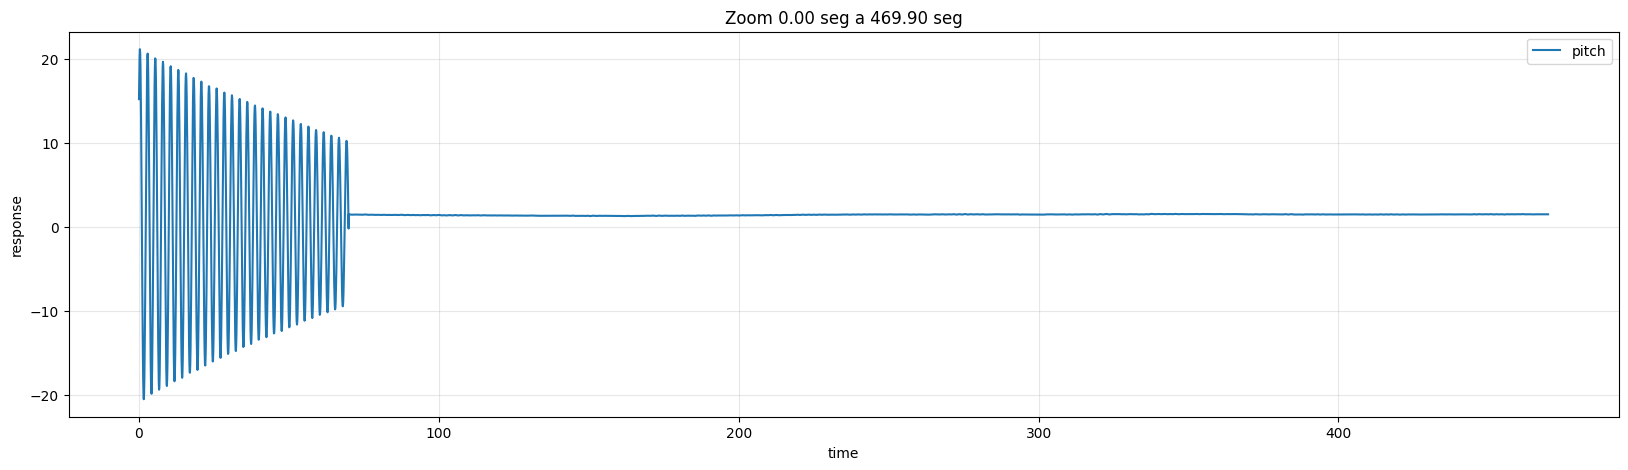

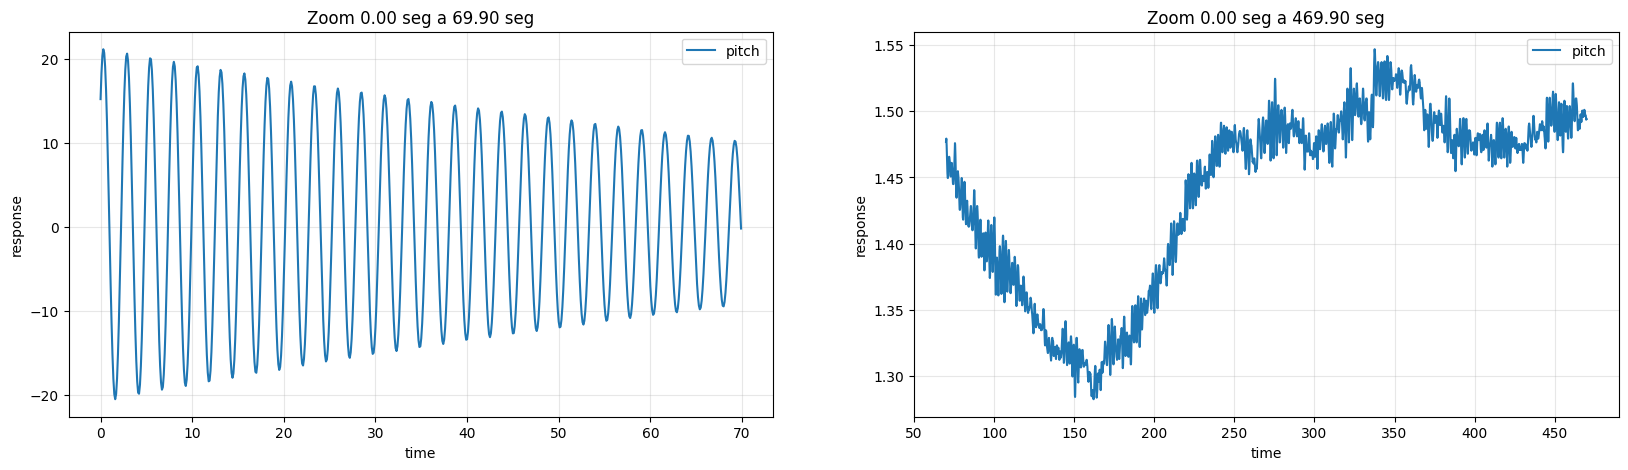

In [115]:
def plotViews(df, limits=(0, 1)):
    VIEW_TIME = (df.time.values[-1]*limits[0], df.time.values[-1]*limits[1])
    target    = df.loc[(df.time >= VIEW_TIME[0]) & (df.time <= VIEW_TIME[1])]

    plt.plot(target.time, target[TARGET_VAR], label=TARGET_VAR)
    plt.grid(alpha=.3); plt.legend(); plt.xlabel('time'); plt.ylabel('response')
    plt.title(f'Zoom {' a '.join([f'{val:.2f} seg' for val in df.time.max()*np.array(limits)])}')


plt.figure(figsize=(20, 5))
plotViews(df, limits=(0, 1))

plt.figure(figsize=(20, 5))
plt.subplot(1, 2, 1)
plotViews(df_dynamic, limits=(0, 1))

plt.subplot(1, 2, 2)
plotViews(df_static, limits=(0, 1))

# SALVANDO DADOS

In [116]:
df = df.rename(columns={col: 'ref_' + col for col in df.columns if col not in ['time', 'static']})
df

,time,ref_wx,ref_az,ref_q1,ref_ay,ref_la_pos_mon_d,ref_ax,ref_roll,ref_q0,ref_yaw,ref_pitch,ref_q3,ref_wy,ref_sample_time,ref_wz,ref_q2,static
0,0.0,3.766625,0.189200,0.7086,-10.550,-0.08849,0.024890,91.157585,0.6483,-28.928639,15.194841,-0.2647,0.346353,105000000.0,-38.044398,-0.08719,False
1,0.1,3.583851,0.167100,0.7128,-10.080,-0.11040,-0.003167,91.558656,0.6386,-28.808318,18.306002,-0.2817,0.370876,205000000.0,-28.292656,-0.06853,False
2,0.2,2.936982,0.094150,0.7158,-9.652,-0.12630,-0.019120,91.902430,0.6316,-28.699456,20.317083,-0.2925,0.368928,305000000.0,-16.965280,-0.05654,False
3,0.3,1.835757,0.010680,0.7175,-9.352,-0.13230,-0.022650,92.131613,0.6282,-28.613512,21.130683,-0.2965,0.363198,405000000.0,-4.724037,-0.05171,False
4,0.4,0.433729,-0.056640,0.7177,-9.253,-0.12690,-0.012660,92.246205,0.6288,-28.636431,20.700965,-0.2941,-0.378209,505000000.0,7.740660,-0.05465,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4696,469.5,-0.006394,-0.008379,0.6544,-9.786,-0.17950,0.085370,89.954374,0.6480,-45.848083,1.495993,-0.2841,-0.027932,605000000.0,0.002796,-0.26670,True
4697,469.6,-0.000966,-0.007153,0.6544,-9.786,-0.17900,0.085840,89.954374,0.6480,-45.848083,1.494847,-0.2841,-0.025669,705000000.0,-0.005810,-0.26670,True
4698,469.7,0.003132,-0.006557,0.6544,-9.786,-0.17860,0.086080,89.954374,0.6480,-45.848083,1.493701,-0.2841,-0.018398,805000000.0,0.015602,-0.26670,True
4699,469.8,0.010153,-0.008756,0.6544,-9.786,-0.17810,0.086660,89.954374,0.6480,-45.853812,1.494274,-0.2841,-0.014118,905000000.0,-0.008417,-0.26680,True


In [117]:
os.makedirs('output', exist_ok=True)
df.to_csv('output/data.csv', index=None)